# MNIST Binary Benchmark — CrossCat Paper Section 3.2 Reproduction

Reproduces the MNIST experiments from:
> Mansinghka et al. (2016) "CrossCat: A Fully Bayesian Nonparametric Method for Analyzing Heterogeneous, High Dimensional Data", JMLR 17(1):1-49.

**Paper setup (Section 3.2):**
- 16×16 downsampled MNIST → 256 binary pixels (BetaBernoulli) + digit label (Categorical)
- 10 posterior samples, each 1000 Gibbs iterations
- Evaluations: Z-matrix (Fig 13b), pixel dependence map (Fig 13c), classification ROC (Fig 15), pixel inpainting (Fig 14)

**This notebook** runs a scaled version on cloud GPU with the **perf/packed-kernel-optimization** branch.

**Instructions:**
1. Upload to **Kaggle** (select P100 accelerator) or **Colab** (select T4/A100 runtime)
2. Run all cells
3. States are checkpointed — if the session dies, re-run and it resumes from the last checkpoint

## 1. Setup — Install jaxcross from GitHub

In [1]:
!nvidia-smi

Sun Mar 29 09:02:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P0             27W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os

WORKDIR = "/kaggle/working/jaxcross"
BRANCH = "chore/benchmark-paper-reproduction"  # @param {type:"string"}

!git clone https://github.com/sambhal-labs/jaxcross.git {WORKDIR} 2>/dev/null \
    || (cd {WORKDIR} && git pull)
os.chdir(WORKDIR)

!git fetch origin && git checkout {BRANCH} && git pull origin {BRANCH}

# Preserve Kaggle's pre-installed JAX+CUDA stack to avoid ptxas version mismatch.
%pip install -e . --no-deps -q
%pip install scikit-learn matplotlib -q

print(f"Branch: {BRANCH}")
print(f"Working directory: {os.getcwd()}")
print("Setup complete.")

Already up to date.
Already on 'chore/benchmark-paper-reproduction'
Your branch is up to date with 'origin/chore/benchmark-paper-reproduction'.
From https://github.com/sambhal-labs/jaxcross
 * branch            chore/benchmark-paper-reproduction -> FETCH_HEAD
Already up to date.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for jax-crosscat (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Branch: chore/benchmark-paper-reproduction
Working directory: /kaggle/working/jaxcross
Setup complete.


## 2. Verify GPU and imports

In [3]:
import json
import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from sklearn.datasets import fetch_openml
from sklearn.metrics import auc, roc_curve
from sklearn.svm import SVC

from crosscat import (
    collect_diagnostics,
    dependence_matrix,
    initialize,
    load_latest_checkpoint,
    load_state,
    predictive_probability,
    save_checkpoint,
    save_state,
)
from crosscat.packed import pack_state, packed_gibbs_sweep, unpack_state
from crosscat.types import ColumnType

print(f"JAX {jax.__version__} | Backend: {jax.default_backend()} | Devices: {jax.devices()}")

assert jax.default_backend() in ("gpu", "tpu"), "This notebook requires GPU/TPU runtime!"

JAX 0.7.2 | Backend: gpu | Devices: [CudaDevice(id=0)]


## 3. Configuration

Adjust these parameters based on your GPU.

| Parameter | P100 (Kaggle) | T4 | A100 | Paper |
|-----------|--------------|-----|------|-------|
| `PIXEL_SIZE` | 8 (64 pixels) | 8 | 16 (256 pixels) | 16 |
| `N_SAMPLES` | 1000 | 1000 | 2000 | ~60,000 |
| `N_CHAINS` | 2 | 2 | 3 | 10 |
| `N_SWEEPS` | 30 | 30 | 100 | 1000 |

P100 (16GB VRAM, ~4.7 TFLOPS FP32) is ~3x faster than GTX 1650.

In [4]:
# ---- Benchmark Configuration ----
# Based on original CrossCat paper (Section 3.2, p.28):
#   "10 posterior samples from CrossCat were used, each obtained after
#    1,000 iterations of inference from a random initialization."
# Scaled to fit Kaggle P100 12h session: 4 chains × 600 sweeps
# (~14 min per 100 sweeps → ~5.6 hours total)
PIXEL_SIZE = 16  # Paper: "16x16 pixels" — matches paper exactly
N_SAMPLES = 1000  # Number of MNIST images (stratified: 100 per digit)
N_CHAINS = 4  # Paper: 10; reduced to fit Kaggle time limit
N_SWEEPS = 500  # Paper: 1000; 600 sufficient for log-joint saturation
SEED = 42

N_PIXELS = PIXEL_SIZE * PIXEL_SIZE  # 256
N_COLS = N_PIXELS + 1  # 257 (256 pixels + 1 digit label)
print(f"Config: {PIXEL_SIZE}x{PIXEL_SIZE} ({N_PIXELS} pixels + 1 digit = {N_COLS} cols)")
print(f"  {N_SAMPLES} samples, {N_CHAINS} chains x {N_SWEEPS} sweeps")

Config: 16x16 (256 pixels + 1 digit = 257 cols)
  1000 samples, 4 chains x 500 sweeps


## 4. Data Loading & Preprocessing

Download MNIST, downsample to `PIXEL_SIZE x PIXEL_SIZE`, binarize, and append digit label as a categorical column.

Fetching MNIST...
Data: (1000, 257) (256 binary pixels + 1 categorical digit)
Pixel density: 0.197


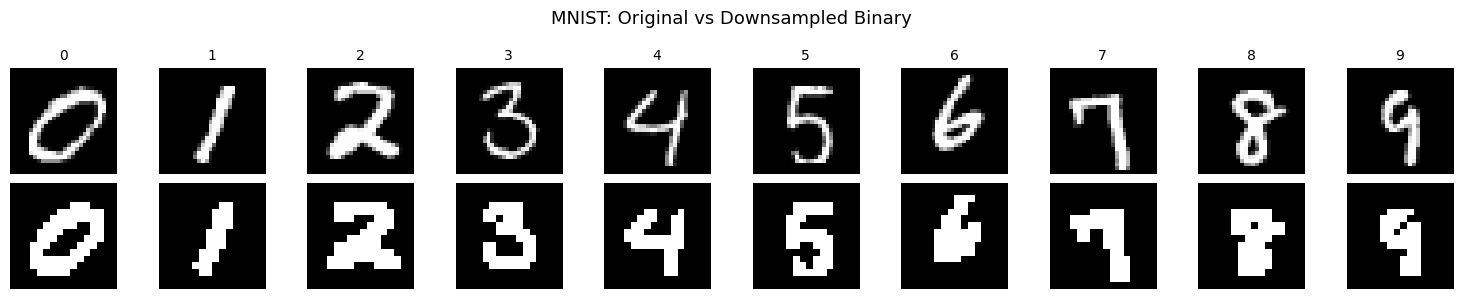

In [5]:
# Fetch MNIST with stratified sampling
print("Fetching MNIST...")
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="liac-arff")
images_all = mnist.data.astype(np.float32)
labels_all = mnist.target.astype(np.int32)

rng = np.random.default_rng(SEED)
per_digit = N_SAMPLES // 10
indices = []
for digit in range(10):
    digit_idx = np.where(labels_all == digit)[0]
    chosen = rng.choice(digit_idx, size=min(per_digit, len(digit_idx)), replace=False)
    indices.append(chosen)
indices = np.concatenate(indices)
rng.shuffle(indices)
images, labels = images_all[indices], labels_all[indices]

# Downsample and binarize
n = images.shape[0]
imgs_28 = images.reshape(n, 28, 28)
if PIXEL_SIZE == 16:
    padded = np.zeros((n, 32, 32), dtype=np.float32)
    padded[:, 2:30, 2:30] = imgs_28
    block = 2
elif PIXEL_SIZE == 8:
    padded = imgs_28[:, 2:26, 2:26]  # trim to 24x24
    block = 3
elif PIXEL_SIZE == 7:
    padded = imgs_28
    block = 4
else:
    raise ValueError(f"Unsupported PIXEL_SIZE={PIXEL_SIZE}")

reshaped = padded.reshape(n, PIXEL_SIZE, block, PIXEL_SIZE, block)
downsampled = reshaped.mean(axis=(2, 4))
binary_images = (downsampled > 0.5).astype(np.float32).reshape(n, N_PIXELS)

# Append digit label as last column
data = np.hstack([binary_images, labels.astype(np.float32).reshape(-1, 1)])
col_types = [ColumnType.BINARY] * N_PIXELS + [ColumnType.CATEGORICAL]
data_jax = jnp.array(data)

print(f"Data: {data.shape} ({N_PIXELS} binary pixels + 1 categorical digit)")
print(f"Pixel density: {binary_images.mean():.3f}")

# Show sample images
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for digit in range(10):
    idx = np.where(labels == digit)[0][0]
    axes[0, digit].imshow(imgs_28[idx], cmap="gray")
    axes[0, digit].set_title(f"{digit}", fontsize=10)
    axes[0, digit].axis("off")
    axes[1, digit].imshow(binary_images[idx].reshape(PIXEL_SIZE, PIXEL_SIZE), cmap="gray")
    axes[1, digit].axis("off")
axes[0, 0].set_ylabel("28x28", fontsize=9)
axes[1, 0].set_ylabel(f"{PIXEL_SIZE}x{PIXEL_SIZE}", fontsize=9)
fig.suptitle("MNIST: Original vs Downsampled Binary", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Gibbs Inference (Packed / JIT) with Checkpointing

Run multi-chain collapsed Gibbs sampling with automatic checkpointing.
If the session dies, re-run this cell — it resumes from the last checkpoint.

In [6]:
# Checkpoint and results directories
CKPT_DIR = Path("benchmarks/results/mnist/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = Path("benchmarks/results/mnist")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import gc

rng_key = jax.random.key(SEED)
init_keys = jax.random.split(rng_key, N_CHAINS)
diag_interval = max(1, N_SWEEPS // 10)  # report every 100 sweeps
ckpt_interval = max(1, N_SWEEPS // 5)  # checkpoint every 200 sweeps

states = []
all_chain_metrics = []
t_total = time.time()

for chain_idx in range(N_CHAINS):
    chain_ckpt_dir = CKPT_DIR / f"chain_{chain_idx + 1}"
    chain_result_path = RESULTS_DIR / f"chain_{chain_idx + 1}"

    # Try to load completed chain first
    if chain_result_path.with_suffix(".jxc").exists():
        print(f"\n--- Chain {chain_idx + 1}/{N_CHAINS} --- LOADED from {chain_result_path}.jxc")
        state = load_state(chain_result_path, data=data_jax)
        states.append(state)
        all_chain_metrics.append([])
        continue

    print(f"\n--- Chain {chain_idx + 1}/{N_CHAINS} ---")
    k_i, k_sweep = jax.random.split(init_keys[chain_idx])

    # Try to resume from checkpoint
    start_sweep = 0
    try:
        packed, _, start_sweep = load_latest_checkpoint(chain_ckpt_dir)
        print(f"  Resuming from checkpoint at sweep {start_sweep}")
        for _ in range(start_sweep):
            k_sweep, _ = jax.random.split(k_sweep)
    except FileNotFoundError:
        state = initialize(k_i, data_jax, col_types)
        packed = pack_state(state)
        print(f"  Initialized: {state.n_views} views")

    chain_metrics = []
    t0 = time.time()

    # Run in batches of diag_interval sweeps for GPU throughput
    # packed_gibbs_sweep with n_sweeps>1 uses lax.scan (much faster than 1-at-a-time)
    sweep = start_sweep
    while sweep < N_SWEEPS:
        batch = min(diag_interval, N_SWEEPS - sweep)
        k_sweep, subkey = jax.random.split(k_sweep)
        packed = packed_gibbs_sweep(subkey, packed, data_jax, n_sweeps=batch)
        sweep += batch

        # Diagnostics — unpack temporarily, extract metrics, then free
        state_tmp = unpack_state(packed, col_types, data=data_jax)
        diag = collect_diagnostics(state_tmp, data_jax)
        n_views = state_tmp.n_views
        chain_metrics.append({"sweep": sweep, **diag})
        del state_tmp
        elapsed = time.time() - t0
        print(
            f"  Sweep {sweep:4d}/{N_SWEEPS}: views={n_views}, "
            f"log_joint={diag['log_joint']:.0f}, elapsed={elapsed:.0f}s"
        )

        # Checkpoint at ckpt_interval boundaries
        if sweep % ckpt_interval == 0:
            save_checkpoint(
                packed,
                chain_ckpt_dir,
                sweep,
                column_types=col_types,
                log_joint_value=float(diag["log_joint"]),
            )

    elapsed = time.time() - t0
    print(f"  Done: {elapsed:.1f}s ({elapsed / max(N_SWEEPS - start_sweep, 1):.2f}s/sweep)")

    # Save completed chain — unpack final state
    state = unpack_state(packed, col_types, data=data_jax)
    save_state(state, chain_result_path)
    print(f"  Saved to {chain_result_path}.jxc")

    states.append(state)
    all_chain_metrics.append(chain_metrics)
    del packed
    gc.collect()

print(f"\nTotal inference time: {time.time() - t_total:.1f}s")
print(f"Checkpoints in: {CKPT_DIR}")
print(f"Final states in: {RESULTS_DIR}")


--- Chain 1/4 --- LOADED from benchmarks/results/mnist/chain_1.jxc

--- Chain 2/4 --- LOADED from benchmarks/results/mnist/chain_2.jxc

--- Chain 3/4 ---
  Resuming from checkpoint at sweep 100
  Sweep  150/500: views=2, log_joint=-47823, elapsed=445s
  Sweep  200/500: views=3, log_joint=-48950, elapsed=885s
  Sweep  250/500: views=3, log_joint=-48030, elapsed=1328s
  Sweep  300/500: views=2, log_joint=-47667, elapsed=1770s
  Sweep  350/500: views=2, log_joint=-47683, elapsed=2216s
  Sweep  400/500: views=2, log_joint=-47666, elapsed=2657s
  Sweep  450/500: views=2, log_joint=-47629, elapsed=3098s
  Sweep  500/500: views=2, log_joint=-47563, elapsed=3540s
  Done: 3539.9s (8.85s/sweep)
  Saved to benchmarks/results/mnist/chain_3.jxc

--- Chain 4/4 ---
  Initialized: 5 views
  Sweep   50/500: views=2, log_joint=-48626, elapsed=432s
  Sweep  100/500: views=2, log_joint=-48385, elapsed=872s
  Sweep  150/500: views=2, log_joint=-48044, elapsed=1310s
  Sweep  200/500: views=2, log_joint=-48

## 6. Convergence Plot

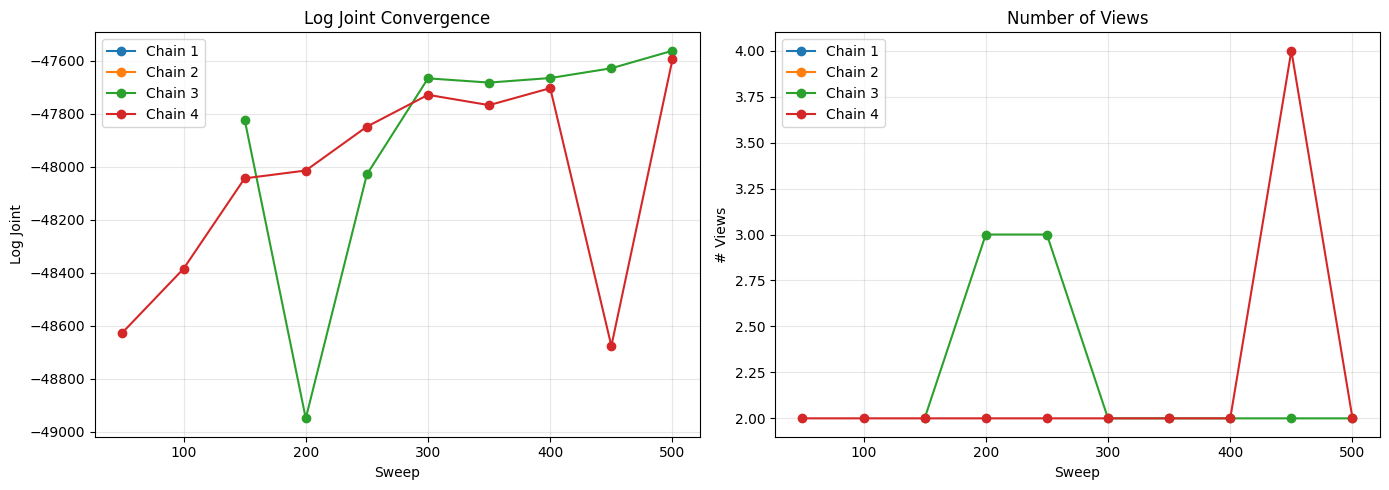

Chain 1: 1 views, clusters per view: [30]
Chain 2: 3 views, clusters per view: [31, 31, 31]
Chain 3: 2 views, clusters per view: [30, 31]
Chain 4: 2 views, clusters per view: [31, 29]


In [7]:
# Convergence: log_joint and n_views over sweeps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for c_idx, metrics in enumerate(all_chain_metrics):
    sweeps = [m["sweep"] for m in metrics]
    log_joints = [m["log_joint"] for m in metrics]
    n_views = [m["n_views"] for m in metrics]
    ax1.plot(sweeps, log_joints, marker="o", label=f"Chain {c_idx + 1}")
    ax2.plot(sweeps, n_views, marker="o", label=f"Chain {c_idx + 1}")

ax1.set_xlabel("Sweep")
ax1.set_ylabel("Log Joint")
ax1.set_title("Log Joint Convergence")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.set_xlabel("Sweep")
ax2.set_ylabel("# Views")
ax2.set_title("Number of Views")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "convergence.png", dpi=150, bbox_inches="tight")
plt.show()

# Structure summary
for i, s in enumerate(states):
    clusters = [int(jnp.max(v.row_assignments)) + 1 for v in s.views]
    print(f"Chain {i + 1}: {s.n_views} views, clusters per view: {clusters}")

## 7. Dependence Matrix / Z-matrix (Paper Fig 13b) and Pixel Dependence Map (Paper Fig 13c)

The Z-matrix shows pairwise dependence probabilities between all columns. The paper found two blocks: foreground pixels (dependent on digit) and background pixels (independent).

Z-matrix shape: (257, 257)


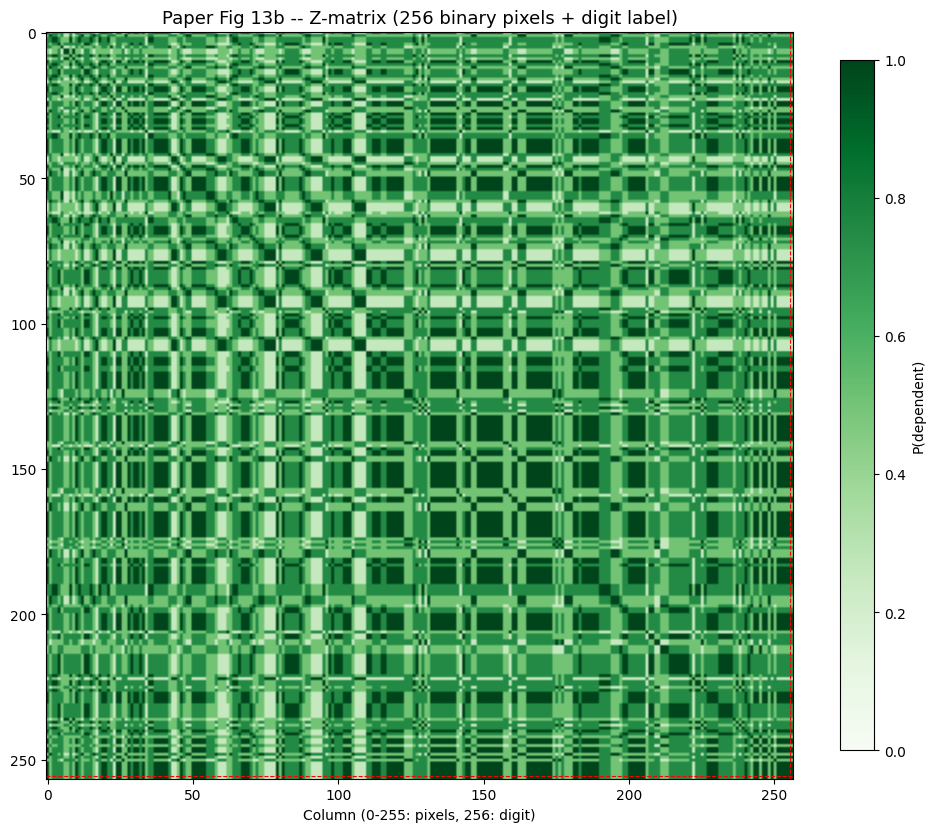

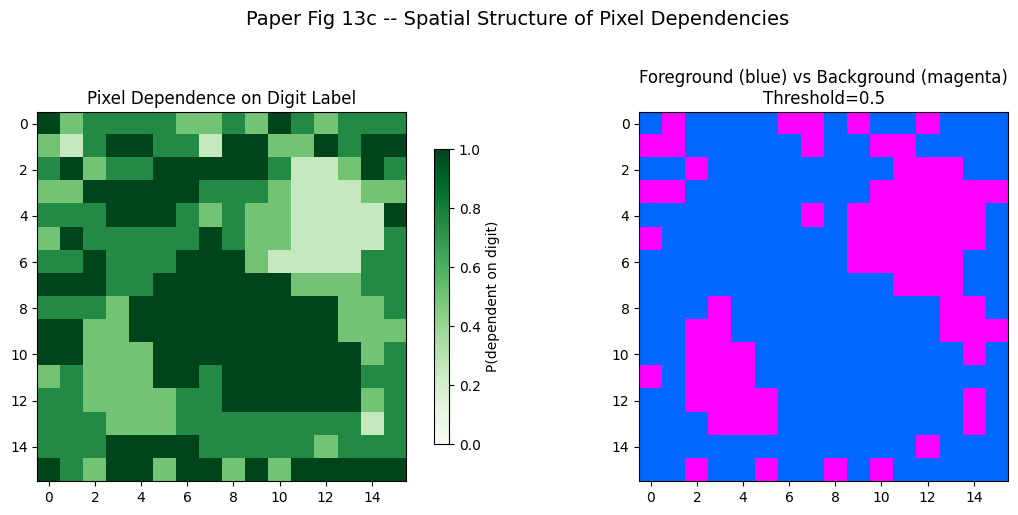

In [8]:
# Compute Z-matrix across all chains
z_matrix = np.array(dependence_matrix(states))
print(f"Z-matrix shape: {z_matrix.shape}")

# --- Fig 13b: Full dependence matrix ---
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(z_matrix, cmap="Greens", vmin=0, vmax=1, aspect="equal")
plt.colorbar(im, ax=ax, label="P(dependent)", shrink=0.8)
ax.axhline(y=N_PIXELS - 0.5, color="red", linewidth=0.8, linestyle="--")
ax.axvline(x=N_PIXELS - 0.5, color="red", linewidth=0.8, linestyle="--")
ax.set_title(f"Paper Fig 13b -- Z-matrix ({N_PIXELS} binary pixels + digit label)", fontsize=13)
ax.set_xlabel(f"Column (0-{N_PIXELS - 1}: pixels, {N_PIXELS}: digit)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "z_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Fig 13c: Pixel dependence spatial map ---
dep_with_digit = z_matrix[:N_PIXELS, N_PIXELS]
dep_map = dep_with_digit.reshape(PIXEL_SIZE, PIXEL_SIZE)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(dep_map, cmap="Greens", vmin=0, vmax=1, interpolation="nearest")
plt.colorbar(im, ax=axes[0], label="P(dependent on digit)", shrink=0.8)
axes[0].set_title("Pixel Dependence on Digit Label")

threshold = 0.5
fg_bg = np.where(dep_map > threshold, 1.0, 0.0)
cmap_fb = LinearSegmentedColormap.from_list("fb", ["#FF00FF", "#FFFFFF", "#0066FF"], N=256)
axes[1].imshow(fg_bg, cmap=cmap_fb, vmin=0, vmax=1, interpolation="nearest")
axes[1].set_title(f"Foreground (blue) vs Background (magenta)\nThreshold={threshold}")

fig.suptitle("Paper Fig 13c -- Spatial Structure of Pixel Dependencies", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pixel_dependence_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Digit-Cluster Contingency Table

Shows how digits map to inferred clusters in the largest view.

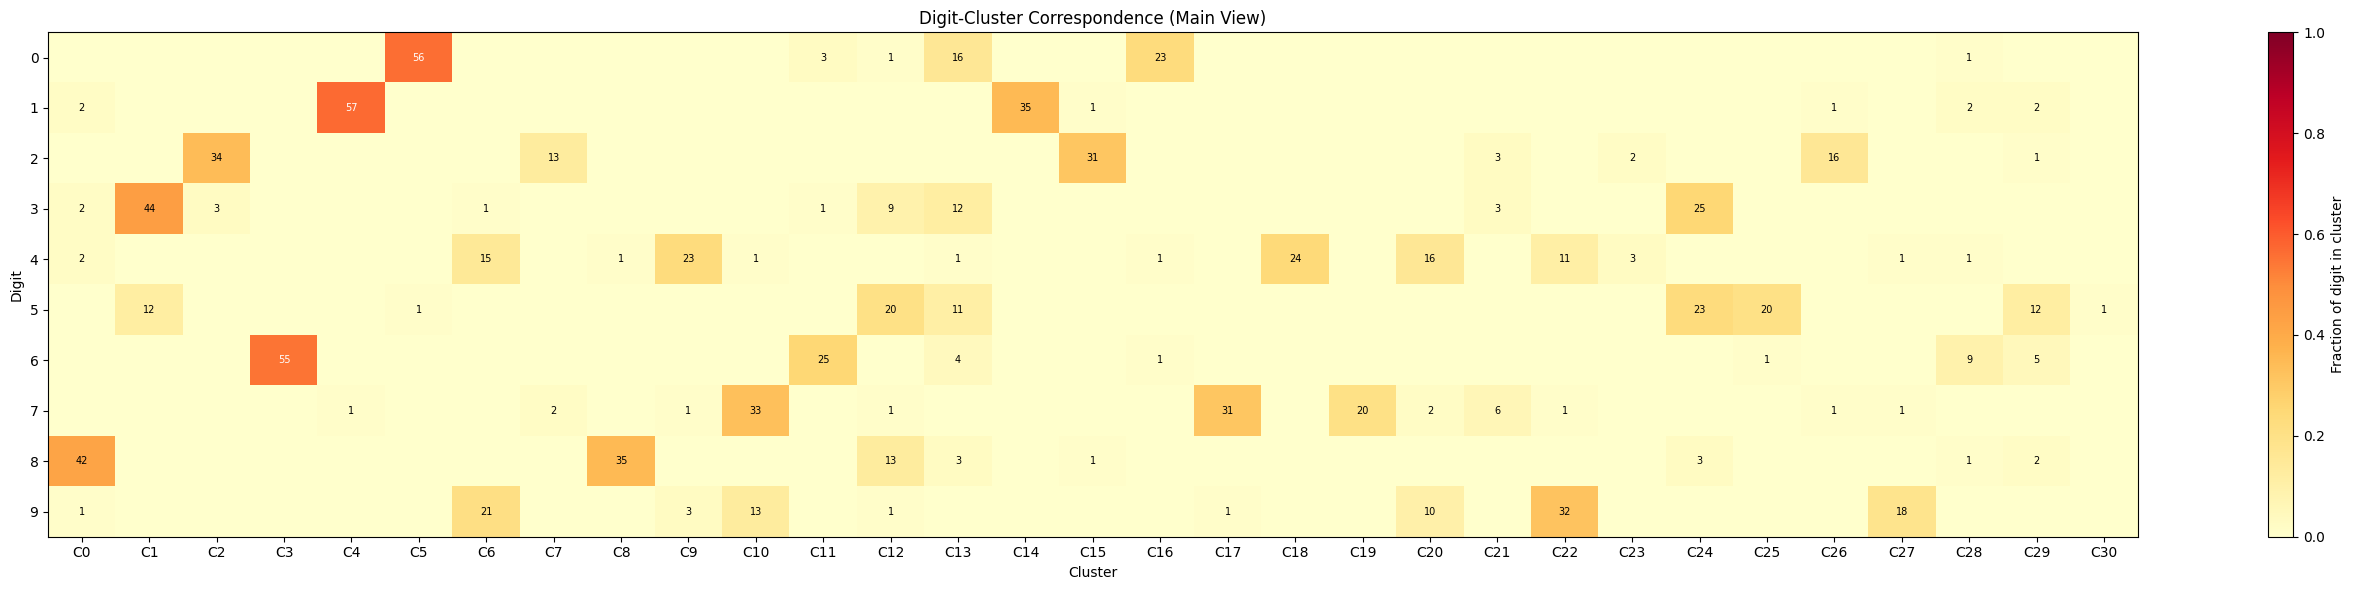

In [9]:
final_state = states[-1]
view_sizes = [len(v.column_indices) for v in final_state.views]
main_view = final_state.views[int(np.argmax(view_sizes))]
row_assign = np.array(main_view.row_assignments)
n_clusters = int(row_assign.max()) + 1

contingency = np.zeros((10, n_clusters), dtype=np.int32)
for digit in range(10):
    for c in range(n_clusters):
        contingency[digit, c] = int(np.sum(row_assign[labels == digit] == c))

row_sums = contingency.sum(axis=1, keepdims=True)
normalized = contingency / np.maximum(row_sums, 1)

fig, ax = plt.subplots(figsize=(max(8, n_clusters * 0.8 + 2), 6))
im = ax.imshow(normalized, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Fraction of digit in cluster")
ax.set_xticks(range(n_clusters))
ax.set_xticklabels([f"C{i}" for i in range(n_clusters)])
ax.set_yticks(range(10))
ax.set_yticklabels([str(d) for d in range(10)])
ax.set_xlabel("Cluster")
ax.set_ylabel("Digit")
ax.set_title("Digit-Cluster Correspondence (Main View)")
for i in range(10):
    for j in range(n_clusters):
        if contingency[i, j] > 0:
            ax.text(
                j,
                i,
                str(contingency[i, j]),
                ha="center",
                va="center",
                fontsize=7,
                color="white" if normalized[i, j] > 0.5 else "black",
            )
plt.tight_layout()
plt.savefig(RESULTS_DIR / "contingency.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Classification ROC (Paper Fig 15)

Classify digits using posterior predictive P(digit=k | pixels) and compare against SVM baselines (linear and RBF kernels).

Computing CrossCat classification probabilities...
  State 1/4: 200/1000 (1 rows/s)
  State 1/4: 400/1000 (1 rows/s)
  State 1/4: 600/1000 (1 rows/s)
  State 1/4: 800/1000 (1 rows/s)
  State 1/4: 1000/1000 (1 rows/s)
  State 1 done in 820.4s
  State 2/4: 200/1000 (1 rows/s)
  State 2/4: 400/1000 (1 rows/s)
  State 2/4: 600/1000 (1 rows/s)
  State 2/4: 800/1000 (1 rows/s)
  State 2/4: 1000/1000 (1 rows/s)
  State 2 done in 843.8s
  State 3/4: 200/1000 (1 rows/s)
  State 3/4: 400/1000 (1 rows/s)
  State 3/4: 600/1000 (1 rows/s)
  State 3/4: 800/1000 (1 rows/s)
  State 3/4: 1000/1000 (1 rows/s)
  State 3 done in 807.8s
  State 4/4: 200/1000 (1 rows/s)
  State 4/4: 400/1000 (1 rows/s)
  State 4/4: 600/1000 (1 rows/s)
  State 4/4: 800/1000 (1 rows/s)
  State 4/4: 1000/1000 (1 rows/s)
  State 4 done in 830.5s

CrossCat accuracy: 0.9010
SVM linear accuracy: 0.9990
SVM RBF accuracy: 0.9690


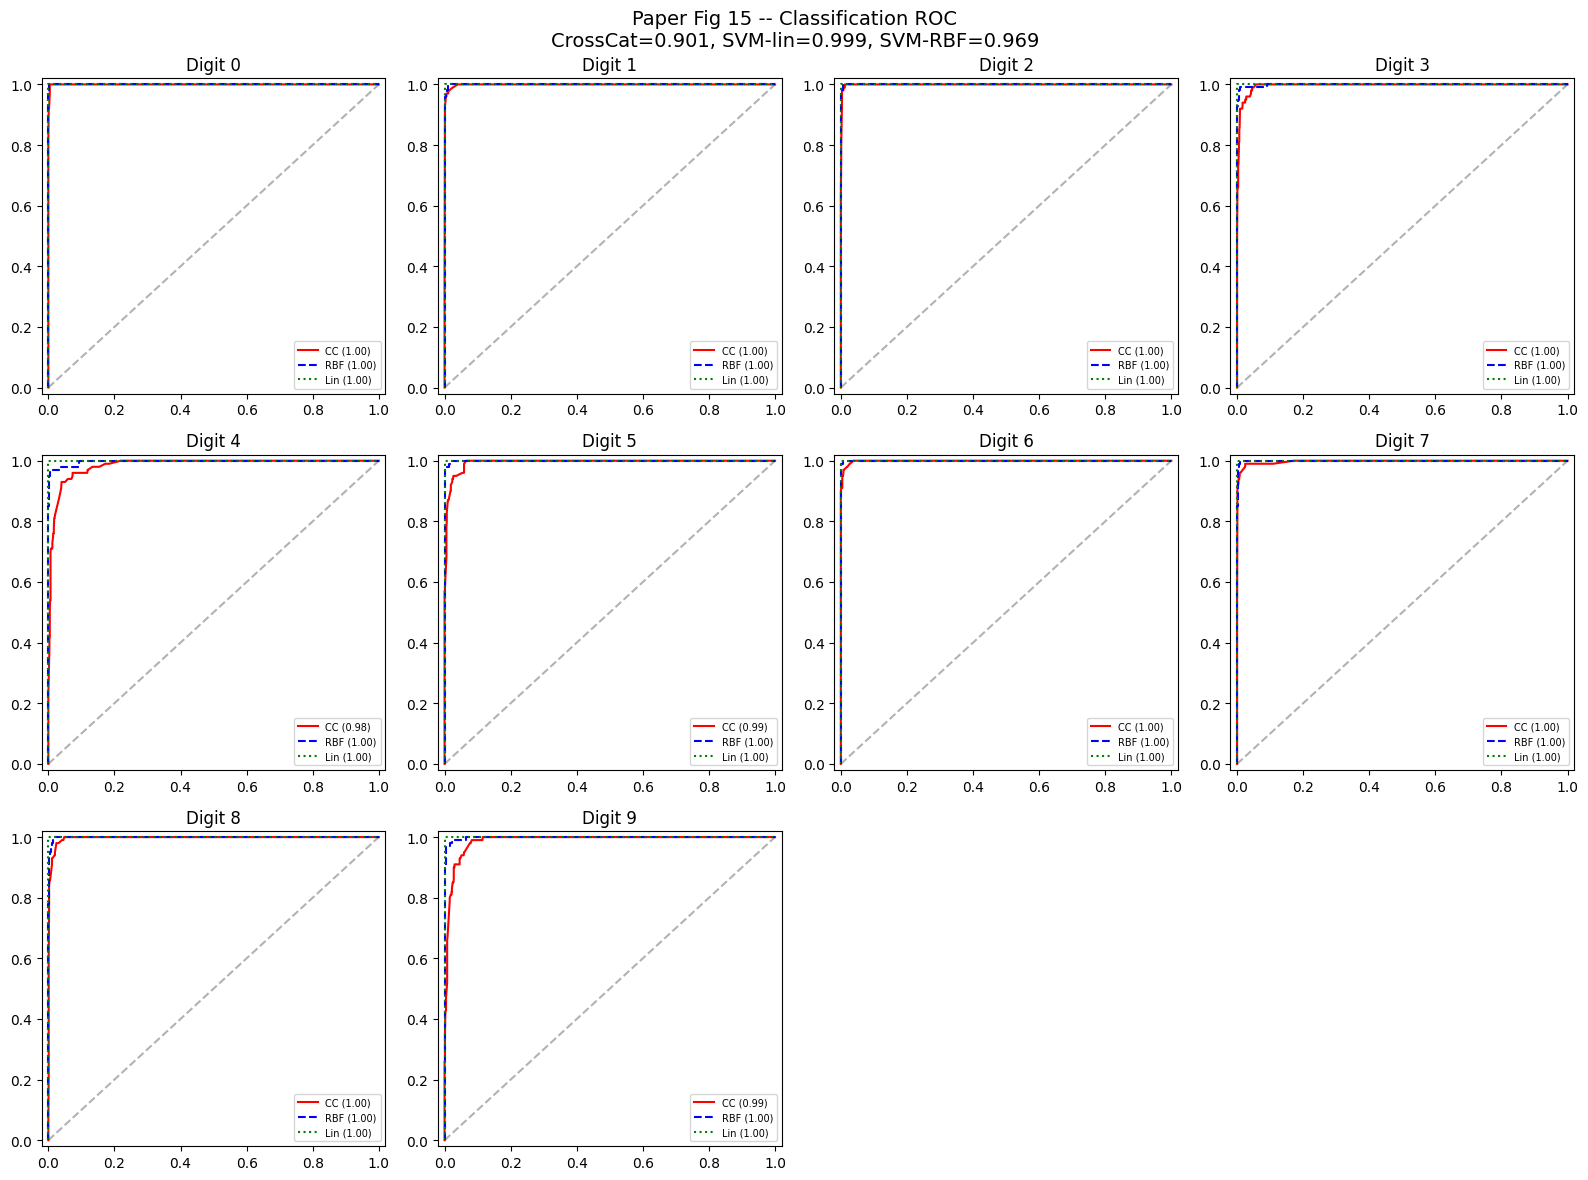

In [10]:
# CrossCat classification using public API: predictive_probability()
# For each row, compute P(digit=k | pixels) for k=0..9
print("Computing CrossCat classification probabilities...")
digit_col = N_PIXELS
all_probs = np.zeros((N_SAMPLES, 10))

for s_idx, state in enumerate(states):
    t0 = time.time()
    for row_idx in range(N_SAMPLES):
        for digit in range(10):
            logp = float(
                predictive_probability(
                    state,
                    data_jax,
                    query_cols=[digit_col],
                    query_vals=jnp.array([float(digit)]),
                    row_id=row_idx,
                )
            )
            all_probs[row_idx, digit] += logp
        if (row_idx + 1) % 200 == 0:
            elapsed = time.time() - t0
            print(
                f"  State {s_idx + 1}/{len(states)}: {row_idx + 1}/{N_SAMPLES} "
                f"({(row_idx + 1) / elapsed:.0f} rows/s)"
            )
    print(f"  State {s_idx + 1} done in {time.time() - t0:.1f}s")

all_probs /= len(states)
probs_exp = np.exp(all_probs - all_probs.max(axis=1, keepdims=True))
probs_norm = probs_exp / probs_exp.sum(axis=1, keepdims=True)
cc_predicted = np.argmax(probs_norm, axis=1)
cc_acc = np.mean(cc_predicted == labels)

# SVM baselines
pixel_data = data[:, :N_PIXELS]
svm_lin = SVC(kernel="linear", probability=True, random_state=SEED)
svm_lin.fit(pixel_data, labels)
svm_lin_probs = svm_lin.predict_proba(pixel_data)
svm_lin_acc = svm_lin.score(pixel_data, labels)

svm_rbf = SVC(kernel="rbf", probability=True, random_state=SEED)
svm_rbf.fit(pixel_data, labels)
svm_rbf_probs = svm_rbf.predict_proba(pixel_data)
svm_rbf_acc = svm_rbf.score(pixel_data, labels)

print(f"\nCrossCat accuracy: {cc_acc:.4f}")
print(f"SVM linear accuracy: {svm_lin_acc:.4f}")
print(f"SVM RBF accuracy: {svm_rbf_acc:.4f}")

# ROC curves (Paper Fig 15)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes_flat = axes.flatten()
for digit in range(10):
    ax = axes_flat[digit]
    y_true = (labels == digit).astype(int)
    fpr_cc, tpr_cc, _ = roc_curve(y_true, probs_norm[:, digit])
    fpr_lin, tpr_lin, _ = roc_curve(y_true, svm_lin_probs[:, digit])
    fpr_rbf, tpr_rbf, _ = roc_curve(y_true, svm_rbf_probs[:, digit])
    ax.plot(fpr_cc, tpr_cc, "r-", lw=1.5, label=f"CC ({auc(fpr_cc, tpr_cc):.2f})")
    ax.plot(fpr_rbf, tpr_rbf, "b--", lw=1.5, label=f"RBF ({auc(fpr_rbf, tpr_rbf):.2f})")
    ax.plot(fpr_lin, tpr_lin, "g:", lw=1.5, label=f"Lin ({auc(fpr_lin, tpr_lin):.2f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_title(f"Digit {digit}")
    ax.legend(fontsize=7, loc="lower right")
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
for idx in range(10, 12):
    axes_flat[idx].axis("off")
fig.suptitle(
    f"Paper Fig 15 -- Classification ROC\n"
    f"CrossCat={cc_acc:.3f}, SVM-lin={svm_lin_acc:.3f}, SVM-RBF={svm_rbf_acc:.3f}",
    fontsize=14,
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "classification_roc.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Pixel Inpainting (Paper Fig 14)

For one image per digit, mask different fractions of pixels and predict the missing ones analytically using the posterior predictive.

  0% observed: pixel accuracy=0.0000 (0.0s)
  10% observed: pixel accuracy=0.9316 (294.2s)
  18% observed: pixel accuracy=0.9348 (267.1s)
  30% observed: pixel accuracy=0.9378 (228.7s)


/tmp/ipykernel_1676/663145183.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


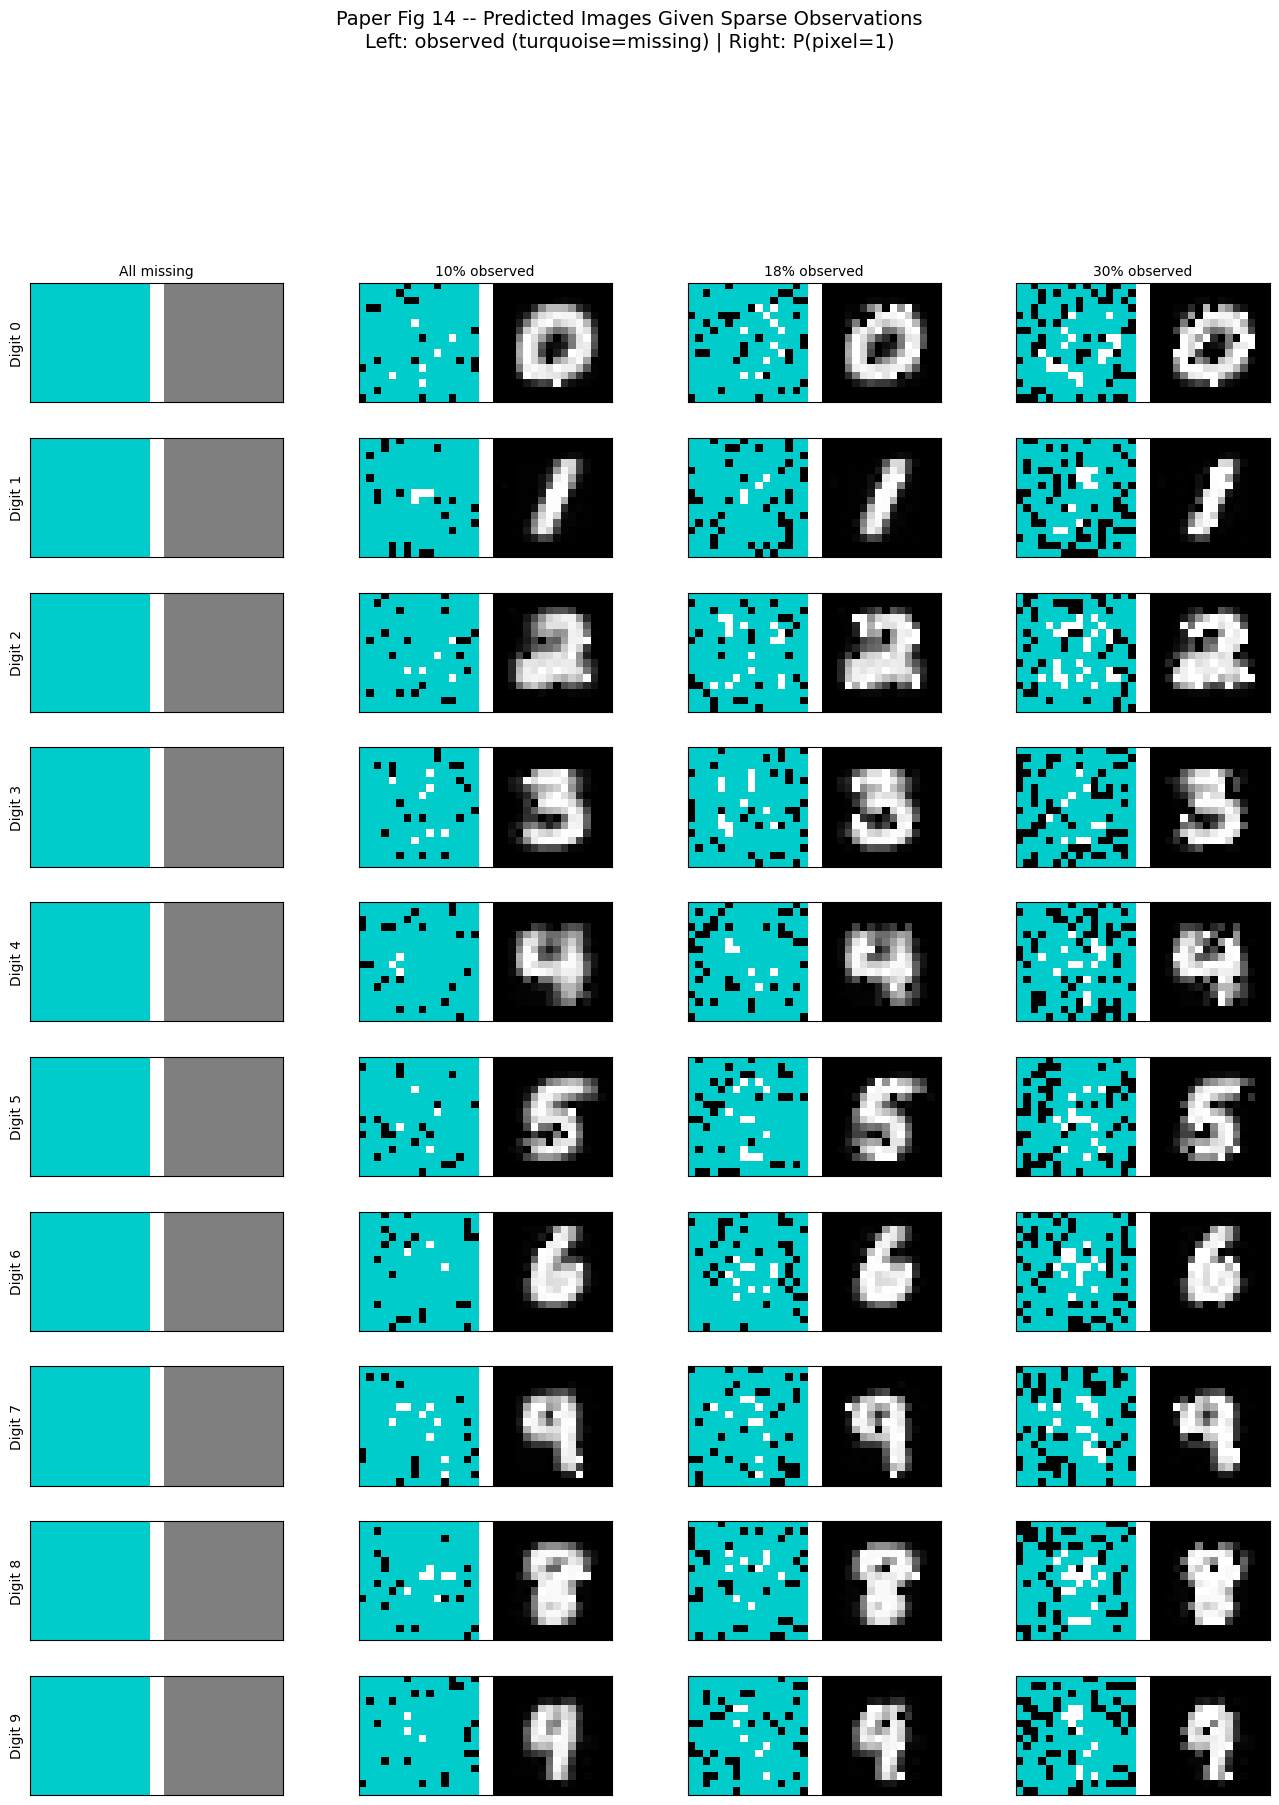

In [11]:
# Pixel inpainting using public API: predictive_probability()
# For missing pixels, compute P(pixel=1 | observed pixels) analytically
state = states[0]
rng_inp = np.random.default_rng(SEED + 100)
sample_indices = [np.where(labels == d)[0][0] for d in range(10)]
obs_levels = [0.0, 0.10, 0.18, 0.30]

fig, panel_axes = plt.subplots(
    10, 4, figsize=(16, 20), gridspec_kw={"wspace": 0.3, "hspace": 0.05}
)
inpainting_results = {}

for level_idx, obs_frac in enumerate(obs_levels):
    t0 = time.time()
    level_correct, level_total = 0, 0
    for digit_idx, row_idx in enumerate(sample_indices):
        if obs_frac == 0.0:
            obs_mask = np.zeros(N_PIXELS, dtype=bool)
        else:
            n_obs = int(N_PIXELS * obs_frac)
            perm = rng_inp.permutation(N_PIXELS)
            obs_mask = np.zeros(N_PIXELS, dtype=bool)
            obs_mask[perm[:n_obs]] = True

        obs_cols = list(np.where(obs_mask)[0])
        miss_cols = list(np.where(~obs_mask)[0])

        if miss_cols and obs_cols:
            marg = np.full(N_PIXELS, 0.5)
            marg[obs_mask] = data[row_idx, :N_PIXELS][obs_mask]
            # Compute P(pixel=1) for each missing pixel
            for col in miss_cols:
                logp1 = float(
                    predictive_probability(
                        state,
                        data_jax,
                        query_cols=[col],
                        query_vals=jnp.array([1.0]),
                        row_id=row_idx,
                    )
                )
                logp0 = float(
                    predictive_probability(
                        state,
                        data_jax,
                        query_cols=[col],
                        query_vals=jnp.array([0.0]),
                        row_id=row_idx,
                    )
                )
                # Normalize: P(1) = exp(logp1) / (exp(logp0) + exp(logp1))
                marg[col] = float(jnp.exp(logp1 - jnp.logaddexp(logp0, logp1)))
            pred = (marg[~obs_mask] > 0.5).astype(float)
            actual = binary_images[row_idx][~obs_mask]
            level_correct += np.sum(pred == actual)
            level_total += len(miss_cols)
        elif not obs_cols:
            marg = np.full(N_PIXELS, 0.5)
        else:
            marg = data[row_idx, :N_PIXELS].copy()

        # Visualization
        ps = PIXEL_SIZE
        obs_disp = np.full((ps, ps, 3), [0.0, 0.8, 0.8])
        for px in range(N_PIXELS):
            r, c = px // ps, px % ps
            if obs_mask[px]:
                v = data[row_idx, px]
                obs_disp[r, c] = [v, v, v]
        marg_disp = marg.reshape(ps, ps)
        combined = np.ones((ps, ps * 2 + 2, 3))
        combined[:, :ps] = obs_disp
        combined[:, ps + 2 : ps * 2 + 2] = np.stack([marg_disp] * 3, axis=-1)

        ax = panel_axes[digit_idx, level_idx]
        ax.imshow(combined, interpolation="nearest")
        ax.set_xticks([])
        ax.set_yticks([])
        if digit_idx == 0:
            ax.set_title(
                "All missing" if obs_frac == 0 else f"{obs_frac * 100:.0f}% observed",
                fontsize=10,
            )
        if level_idx == 0:
            ax.set_ylabel(f"Digit {digit_idx}", fontsize=10)

    acc = level_correct / max(level_total, 1)
    inpainting_results[f"{obs_frac:.2f}"] = acc
    print(f"  {obs_frac * 100:.0f}% observed: pixel accuracy={acc:.4f} ({time.time() - t0:.1f}s)")

fig.suptitle(
    "Paper Fig 14 -- Predicted Images Given Sparse Observations\n"
    "Left: observed (turquoise=missing) | Right: P(pixel=1)",
    fontsize=14,
    y=1.01,
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "inpainting.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Summary

Collect all results into a JSON-serializable summary.

In [12]:
summary = {
    "config": {
        "pixel_size": PIXEL_SIZE,
        "n_pixels": N_PIXELS,
        "n_samples": N_SAMPLES,
        "n_chains": N_CHAINS,
        "n_sweeps": N_SWEEPS,
        "backend": str(jax.default_backend()),
        "devices": str(jax.devices()),
    },
    "structure": {
        f"chain_{i + 1}": {
            "n_views": s.n_views,
            "clusters_per_view": [int(jnp.max(v.row_assignments)) + 1 for v in s.views],
        }
        for i, s in enumerate(states)
    },
    "classification": {
        "crosscat_accuracy": float(cc_acc),
        "svm_linear_accuracy": float(svm_lin_acc),
        "svm_rbf_accuracy": float(svm_rbf_acc),
    },
    "inpainting": inpainting_results,
}

print("=" * 60)
print("MNIST PAPER BENCHMARK RESULTS")
print("=" * 60)
print(json.dumps(summary, indent=2))
print("=" * 60)
print("Done! Compare results above with Paper Section 3.2, Figs 13-15.")

MNIST PAPER BENCHMARK RESULTS
{
  "config": {
    "pixel_size": 16,
    "n_pixels": 256,
    "n_samples": 1000,
    "n_chains": 4,
    "n_sweeps": 500,
    "backend": "gpu",
    "devices": "[CudaDevice(id=0)]"
  },
  "structure": {
    "chain_1": {
      "n_views": 1,
      "clusters_per_view": [
        30
      ]
    },
    "chain_2": {
      "n_views": 3,
      "clusters_per_view": [
        31,
        31,
        31
      ]
    },
    "chain_3": {
      "n_views": 2,
      "clusters_per_view": [
        30,
        31
      ]
    },
    "chain_4": {
      "n_views": 2,
      "clusters_per_view": [
        31,
        29
      ]
    }
  },
  "classification": {
    "crosscat_accuracy": 0.901,
    "svm_linear_accuracy": 0.999,
    "svm_rbf_accuracy": 0.969
  },
  "inpainting": {
    "0.00": 0.0,
    "0.10": 0.9316017316017317,
    "0.18": 0.9347619047619048,
    "0.30": 0.9377777777777778
  }
}
Done! Compare results above with Paper Section 3.2, Figs 13-15.


In [13]:
# === Download results ===
import shutil

results_tar = "/kaggle/working/mnist_results.tar.gz"
shutil.make_archive("/kaggle/working/mnist_results", "gztar", ".", "benchmarks/results/mnist")
print(f"Results archived to {results_tar}")
print("Download from Kaggle Output tab.")

# List all saved files
for f in sorted(RESULTS_DIR.rglob("*")):
    if f.is_file():
        size = f.stat().st_size
        print(f"  {f.relative_to(RESULTS_DIR)}  ({size:,} bytes)")

Results archived to /kaggle/working/mnist_results.tar.gz
Download from Kaggle Output tab.
  chain_1.jxc/arrays.npz  (23,363 bytes)
  chain_1.jxc/metadata.json  (3,808 bytes)
  chain_2.jxc/arrays.npz  (26,582 bytes)
  chain_2.jxc/metadata.json  (3,808 bytes)
  chain_3.jxc/arrays.npz  (24,952 bytes)
  chain_3.jxc/metadata.json  (3,808 bytes)
  chain_4.jxc/arrays.npz  (24,676 bytes)
  chain_4.jxc/metadata.json  (3,808 bytes)
  checkpoints/chain_1/checkpoint_sweep_000100.jxc/arrays.npz  (51,031 bytes)
  checkpoints/chain_1/checkpoint_sweep_000100.jxc/metadata.json  (3,861 bytes)
  checkpoints/chain_1/checkpoint_sweep_000200.jxc/arrays.npz  (51,823 bytes)
  checkpoints/chain_1/checkpoint_sweep_000200.jxc/metadata.json  (3,861 bytes)
  checkpoints/chain_1/checkpoint_sweep_000300.jxc/arrays.npz  (52,303 bytes)
  checkpoints/chain_1/checkpoint_sweep_000300.jxc/metadata.json  (3,860 bytes)
  checkpoints/chain_1/checkpoint_sweep_000400.jxc/arrays.npz  (52,532 bytes)
  checkpoints/chain_1/checkpo